# Dense And Sparse Correspondence
In this tutorial we show how DINOv3 features can be used to establish correspondences between two objects.

### Setup

Let's start by loading some pre-requisites and checking the DINOv3 repository location:
- `local` if `DINOV3_LOCATION` environment variable was set to work with a local version of DINOv3 repository;
- `github` if the code should be loaded via torch hub.

In [1]:
import json
import pickle
import os
from pathlib import Path

import cv2
import numpy as np
from matplotlib.patches import ConnectionPatch
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA

import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from tqdm import tqdm

from origami_texturing.paths import EXTERNAL_DIR, NOTEBOOKS_DIR, INPUTS_DIR, RAW_DATA_DIR

DINOV3_LOCAL_LOCATION = EXTERNAL_DIR / "dinov3"
DINOV3_GITHUB_LOCATION = "facebookresearch/dinov3"

if os.getenv("DINOV3_LOCATION") is not None:
    DINOV3_LOCATION = os.getenv("DINOV3_LOCATION")
elif DINOV3_LOCAL_LOCATION.exists():
    DINOV3_LOCATION = str(DINOV3_LOCAL_LOCATION)
else:
    DINOV3_LOCATION = DINOV3_GITHUB_LOCATION

print(f"DINOv3 location set to {DINOV3_LOCATION}")

DINOv3 location set to C:\Users\morph\GitHub\origami-texturing\external\dinov3


### Model Loading
We load the DINOv3 ViT-H+ model. Feel free to try other DINOv3 models as well!

In [2]:
# examples of available DINOv3 models:
MODEL_DINOV3_VITS = "dinov3_vits16"
MODEL_DINOV3_VITSP = "dinov3_vits16plus"
MODEL_DINOV3_VITB = "dinov3_vitb16"
MODEL_DINOV3_VITL = "dinov3_vitl16"
MODEL_DINOV3_VITHP = "dinov3_vith16plus"
MODEL_DINOV3_VIT7B = "dinov3_vit7b16"

MODEL_NAME = MODEL_DINOV3_VITHP

from origami_texturing.paths import MODELS_DIR
WEIGHTS = str(MODELS_DIR / "dinov3" / "dinov3_vith16plus.pth")

model = torch.hub.load(
    repo_or_dir=DINOV3_LOCATION,
    model="dinov3_vith16plus",
    source="local",
    weights=WEIGHTS,
)
model.cuda()

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1280, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-31): 32 x SelfAttentionBlock(
      (norm1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=1280, out_features=3840, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1280, out_features=1280, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (mlp): SwiGLUFFN(
        (w1): Linear(in_features=1280, out_features=5120, bias=True)
        (w2): Linear(in_features=1280, out_features=5120, bias=True)
        (w3): Linear(in_features=5120, out_features=1280, bias=True)
      )
      (ls2): LayerScale()
    )
  )
  (norm): LayerNorm((

### Data Loading
Now that we have the model set up, let's load the two input images (target.png and reference.png with backgrounds already removed).


In [3]:
target_image_path = RAW_DATA_DIR / "target.png"
reference_image_path = RAW_DATA_DIR / "reference.png"


def load_image_with_alpha(path: Path) -> tuple[Image.Image, torch.Tensor]:
    """Load image with RGBA and extract alpha mask."""
    img_rgba = Image.open(path).convert("RGBA")
    img_rgb = img_rgba.convert("RGB")
    
    # Extract alpha channel as mask (1 = opaque, 0 = transparent)
    alpha = np.array(img_rgba.split()[3], dtype=np.float32) / 255.0
    alpha_mask = torch.from_numpy(alpha)
    
    return img_rgb, alpha_mask


def image_on_black(image: Image.Image, alpha_mask: torch.Tensor | None = None) -> np.ndarray:
    image_rgba = image.convert("RGBA")
    image_np = np.array(image_rgba, dtype=np.float32)
    alpha = image_np[..., 3:4] / 255.0

    if alpha_mask is not None:
        alpha = alpha_mask.detach().cpu().numpy()[..., None].astype(np.float32)

    return np.clip(image_np[..., :3] * alpha, 0, 255).astype(np.uint8)


target_image, target_alpha_mask = load_image_with_alpha(target_image_path)
reference_image, reference_alpha_mask = load_image_with_alpha(reference_image_path)

print(f"Loaded target image from {target_image_path}")
print(f"Loaded reference image from {reference_image_path}")
print(f"Target mask shape: {target_alpha_mask.shape}, Reference mask shape: {reference_alpha_mask.shape}")


Loaded target image from C:\Users\morph\GitHub\origami-texturing\data\raw\target.png
Loaded reference image from C:\Users\morph\GitHub\origami-texturing\data\raw\reference.png
Target mask shape: torch.Size([1024, 1024]), Reference mask shape: torch.Size([1254, 1254])


Let's visualize the two input images:


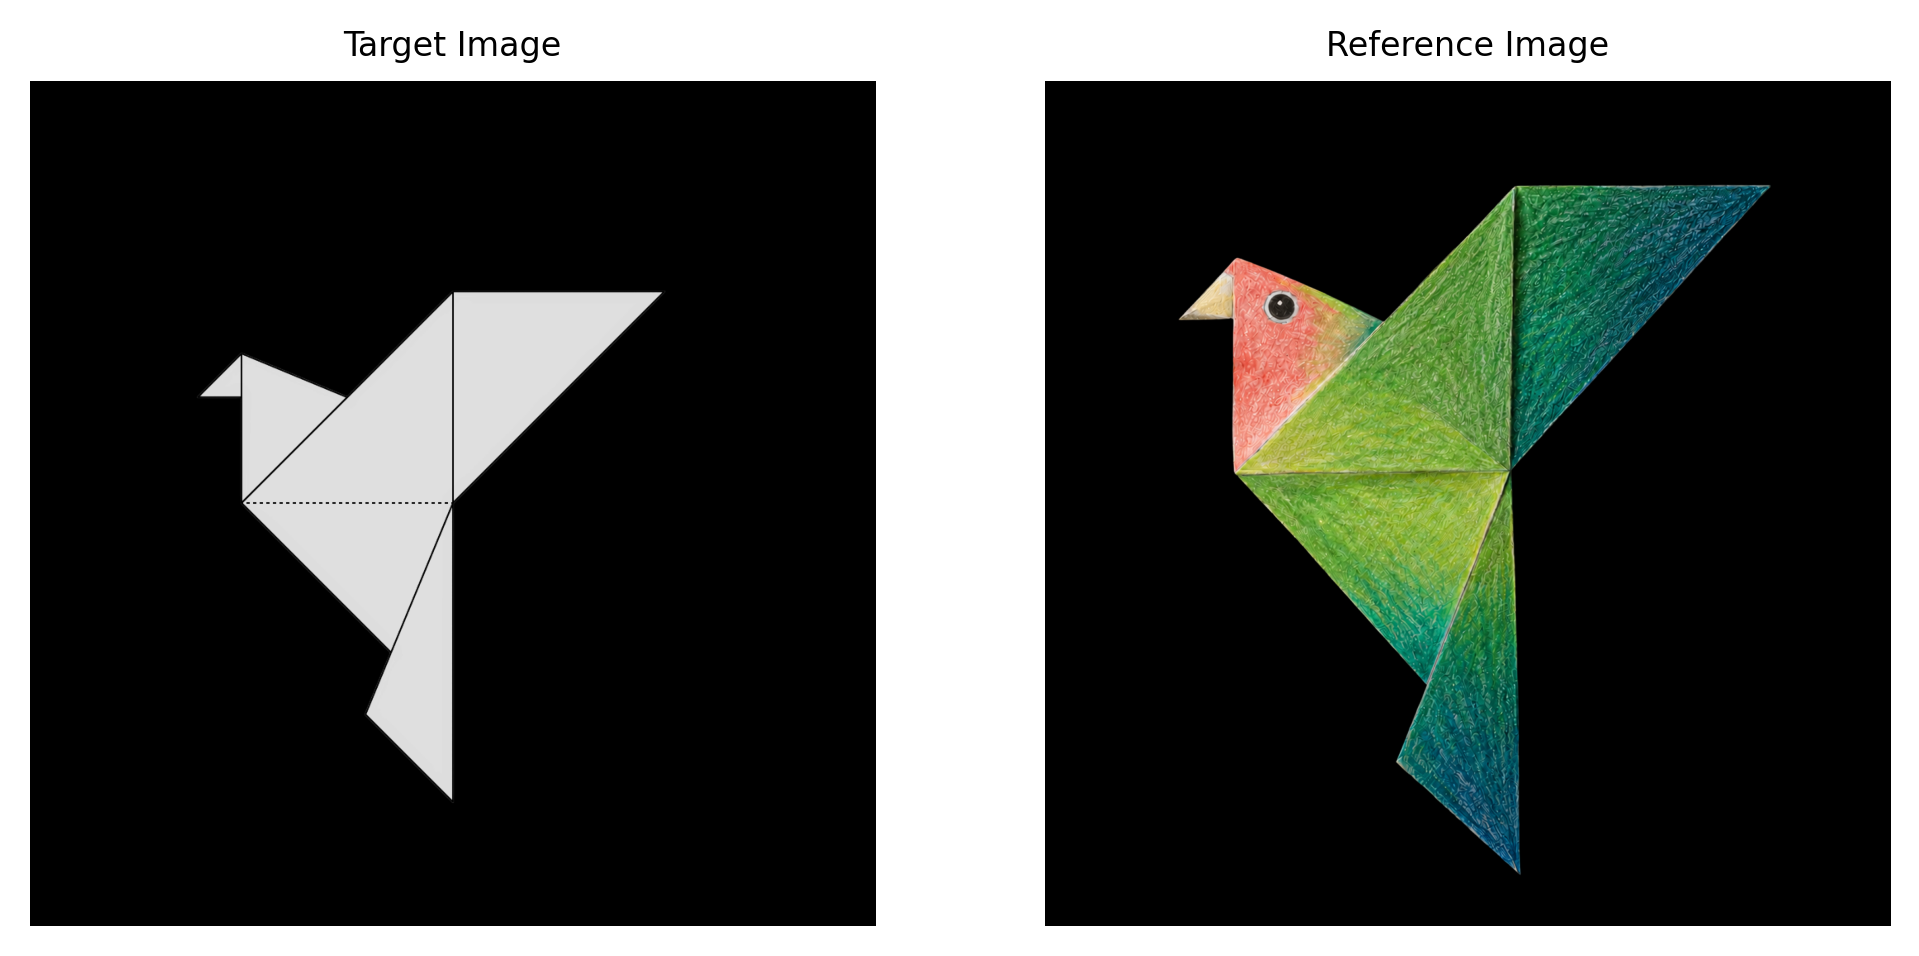

In [4]:
plt.figure(figsize=(8, 4), dpi=300)

for j, (image, alpha_mask) in enumerate([(target_image, target_alpha_mask), (reference_image, reference_alpha_mask)]):
    plt.subplot(1, 2, j + 1)
    plt.imshow(image_on_black(image, alpha_mask))
    plt.axis("off")
    plt.title(["Target Image", "Reference Image"][j], fontsize=8)

plt.show()


### Data Transforms

Since our models run with a patch size of 16, we resize each image such that it aligns well with the 16x16 grid. The alpha mask is also resized to the patch grid for masking transparent regions.


In [5]:
PATCH_SIZE = 16
IMAGE_SIZE = 1024

# image resize transform to dimensions divisible by patch size
def resize_transform(
    image: Image.Image,
    image_size: int = IMAGE_SIZE,
    patch_size: int = PATCH_SIZE,
) -> torch.Tensor:
    w, h = image.size
    h_patches = int(image_size / patch_size)
    w_patches = int((w * image_size) / (h * patch_size))
    return TF.to_tensor(TF.resize(image, (h_patches * patch_size, w_patches * patch_size)))


def patch_scores_to_alpha_image(patch_scores: torch.Tensor, image_size: tuple[int, int]) -> Image.Image:
    width, height = image_size
    alpha = TF.resize(
        patch_scores.unsqueeze(0),
        (height, width),
        interpolation=TF.InterpolationMode.BILINEAR,
    ).squeeze(0)
    alpha_np = (alpha.clamp(0, 1).numpy() * 255).astype(np.uint8)
    return Image.fromarray(alpha_np, mode="L")


### Extracting Features
Now we extract DINOv3 patch features for the two images.

Each tensor of patch features has shape `[D, H, W]`, where `D` is feature dimensionality, and `H` and `W` are image dimensions in the number of patches.


In [6]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

MODEL_TO_NUM_LAYERS = {
    MODEL_DINOV3_VITS: 12,
    MODEL_DINOV3_VITSP: 12,
    MODEL_DINOV3_VITB: 12,
    MODEL_DINOV3_VITL: 24,
    MODEL_DINOV3_VITHP: 32,
    MODEL_DINOV3_VIT7B: 40,
}

n_layers = MODEL_TO_NUM_LAYERS[MODEL_NAME]

patch_features = []
patch_masks = []

with torch.inference_mode():
    with torch.autocast(device_type="cuda", dtype=torch.float32):
        for idx, (image, alpha_mask) in enumerate(
            tqdm(
                [(target_image, target_alpha_mask), (reference_image, reference_alpha_mask)],
                desc="Processing images"
            )
        ):
            image_resized = resize_transform(image)
            image_resized = TF.normalize(image_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)
            image_resized = image_resized.unsqueeze(0).cuda()

            feats = model.get_intermediate_layers(image_resized, n=range(n_layers), reshape=True, norm=True)
            feature_map = feats[-1].squeeze().detach().cpu()
            dim, h_patches, w_patches = feature_map.shape
            patch_features.append(feature_map)
            
            # Resize alpha mask to patch grid
            alpha_mask_resized = TF.resize(
                alpha_mask.unsqueeze(0),
                (h_patches, w_patches),
                interpolation=TF.InterpolationMode.BILINEAR,
            ).squeeze(0)
            patch_masks.append(alpha_mask_resized)

print("Feature extraction complete!")
print(f"Patch features shapes: {[f.shape for f in patch_features]}")
print(f"Patch masks shapes: {[m.shape for m in patch_masks]}")


Processing images: 100%|██████████| 2/2 [00:01<00:00,  1.61it/s]

Feature extraction complete!
Patch features shapes: [torch.Size([1280, 64, 64]), torch.Size([1280, 64, 64])]
Patch masks shapes: [torch.Size([64, 64]), torch.Size([64, 64])]


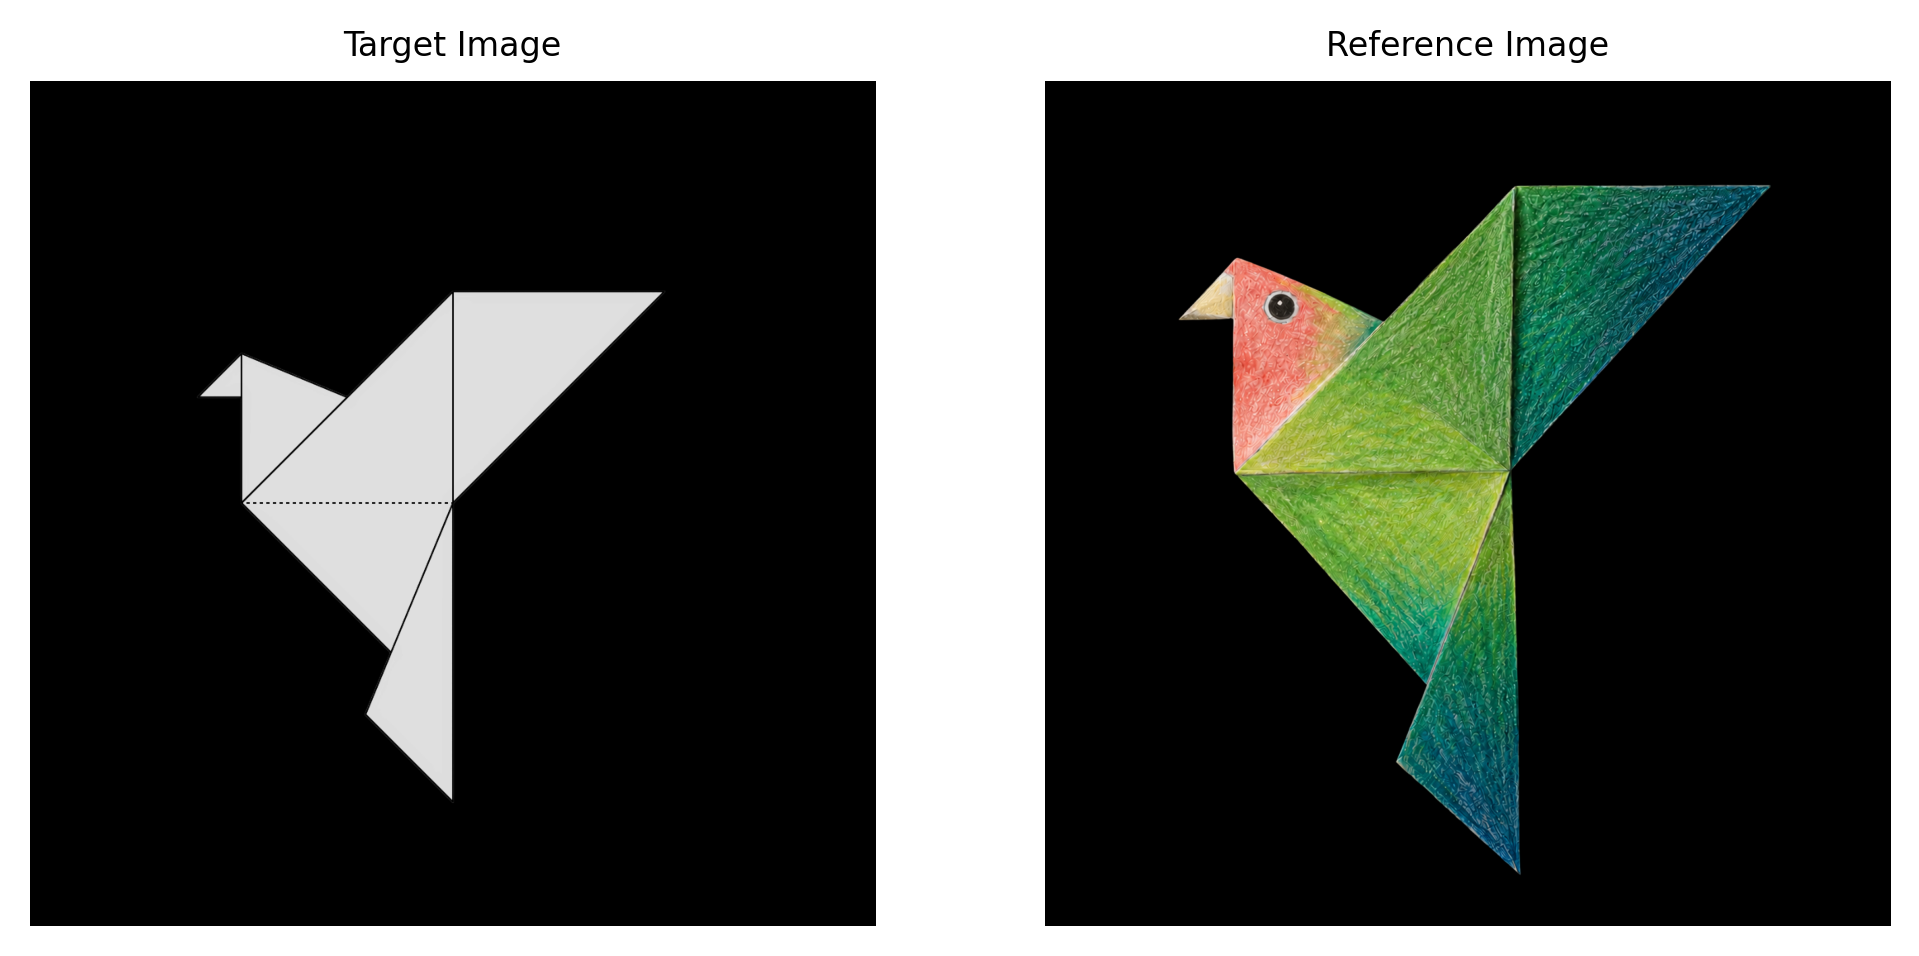

In [7]:
plt.figure(figsize=(8, 4), dpi=300)

for j, (image, alpha_mask) in enumerate([(target_image, target_alpha_mask), (reference_image, reference_alpha_mask)]):
    plt.subplot(1, 2, j + 1)
    plt.imshow(image_on_black(image, alpha_mask))
    plt.axis("off")
    plt.title(["Target Image", "Reference Image"][j], fontsize=8)

plt.show()


### Matching Patches

For each patch within the foreground object in the target image, we search for the closest patch in the reference image using [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity) between patch features. The alpha channel from the transparent background is used to mask out transparent regions.


In [8]:
MASK_FG_THRESHOLD = 0.5

patch_features[0] = F.normalize(patch_features[0], p=2, dim=0)
patch_features[1] = F.normalize(patch_features[1], p=2, dim=0)

heatmaps = torch.einsum(
    "k f, f h w -> k h w",
    patch_features[0].view(dim, -1).permute(1, 0),
    patch_features[1],
)

# Apply mask to heatmaps - set transparent regions to -inf
target_fg_mask = patch_masks[0] > MASK_FG_THRESHOLD
reference_fg_mask = patch_masks[1] > MASK_FG_THRESHOLD

# Flatten target mask to match heatmap's first dimension
target_fg_mask_flat = target_fg_mask.view(-1)  # [n_patches_target]

heatmaps_masked = heatmaps.clone()
# Mask out patches where target image is transparent (entire row becomes -inf)
heatmaps_masked[~target_fg_mask_flat, :, :] = -torch.inf
# Mask out patches where reference image is transparent (all rows, specific locations)
heatmaps_masked[:, ~reference_fg_mask] = -torch.inf

# compute 2D patch locations in the target image
n_patches_target = patch_features[0].shape[1] * patch_features[0].shape[2]
patch_indices_target = torch.arange(n_patches_target)
locs_2d_target = (
    torch.stack(
        (
            patch_indices_target // patch_features[0].shape[2],  # row
            patch_indices_target % patch_features[0].shape[2]    # column
        ),
        dim=-1
    ) + 0.5
) * PATCH_SIZE

# compute the corresponding 2D patch locations in the reference image
patch_indices_reference = torch.flatten(heatmaps_masked, start_dim=-2).argmax(dim=-1)
locs_2d_reference = (
    torch.stack(
        (
            patch_indices_reference // patch_features[1].shape[2],  # row
            patch_indices_reference % patch_features[1].shape[2]    # column
        ),
        dim=-1
    ) + 0.5
) * PATCH_SIZE

# select only foreground patches
patches_target_fg_selection = target_fg_mask_flat
patches_reference_fg_selection = reference_fg_mask.view(-1)[patch_indices_reference]
patches_fg_selection = (patches_target_fg_selection * patches_reference_fg_selection)

# select (row, col) coordinates for the matched patches
locs_2d_target_fg = locs_2d_target[patches_fg_selection, :]
locs_2d_reference_fg = locs_2d_reference[patches_fg_selection, :]


### Dense Correspondence
We now show dense correspondences between patches using the color space estimated through PCA over foreground patches in the target image. Closer colors correspond to more similar patches.

In [9]:
pca = PCA(n_components=3, whiten=True)
fg_patches_target = patch_features[0].view(dim, -1).permute(1, 0)[patches_target_fg_selection]
pca.fit(fg_patches_target)


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",3
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",True
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD s

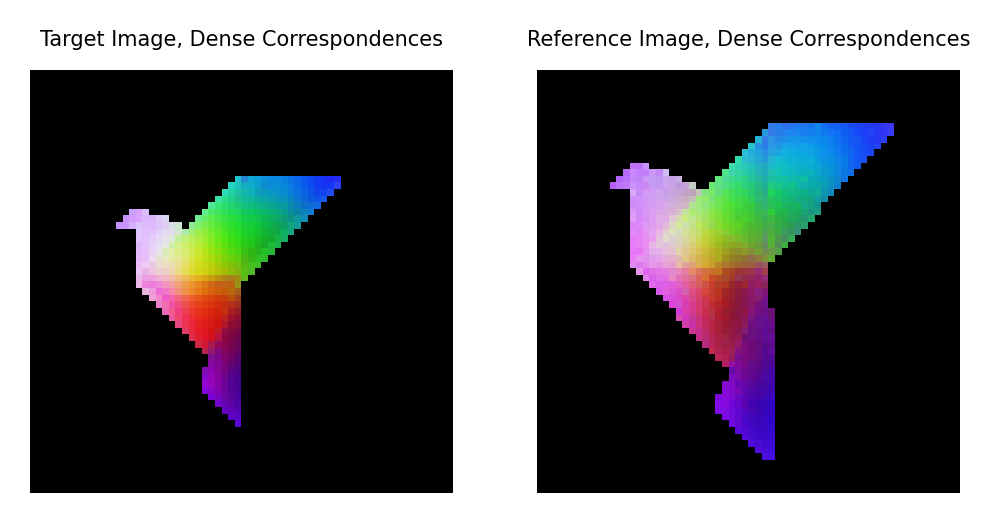

In [10]:
# get colors for the target image
h_patches_target = patch_features[0].shape[1]
w_patches_target = patch_features[0].shape[2]
x_target = patch_features[0].view(dim, -1).permute(1, 0)
projected_image_target = torch.from_numpy(
    pca.transform(x_target.numpy())
).view(h_patches_target, w_patches_target, 3)
# multiply by 2.0 and pass through a sigmoid to get vibrant colors 
projected_image_target = torch.nn.functional.sigmoid(projected_image_target.mul(2.0)).permute(2, 0, 1)

# get colors for the reference image
h_patches_reference = patch_features[1].shape[1]
w_patches_reference = patch_features[1].shape[2]
x_reference = patch_features[1].view(dim, -1).permute(1, 0)
projected_image_reference = torch.from_numpy(
    pca.transform(x_reference.numpy())
).view(h_patches_reference, w_patches_reference, 3)
projected_image_reference = torch.nn.functional.sigmoid(projected_image_reference.mul(2.0)).permute(2, 0, 1)

# apply alpha masks to both visualizations
projected_image_target *= (patch_masks[0] > MASK_FG_THRESHOLD)[None, :, :]
projected_image_reference *= (patch_masks[1] > MASK_FG_THRESHOLD)[None, :, :]

plt.figure(figsize=(4, 2), dpi=300)
plt.subplot(1, 2, 1)
plt.imshow(projected_image_target.permute(1, 2, 0))
plt.title("Target Image, Dense Correspondences", fontsize=5)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(projected_image_reference.permute(1, 2, 0))
plt.title("Reference Image, Dense Correspondences", fontsize=5)
plt.axis('off')
plt.show()


### Sparse Correspondence

Finally, we show the established correspondences via the sparse set of matched points.

Loaded 11 target vertices from C:\Users\morph\GitHub\origami-texturing\data\raw\dove-wingup-topology.json


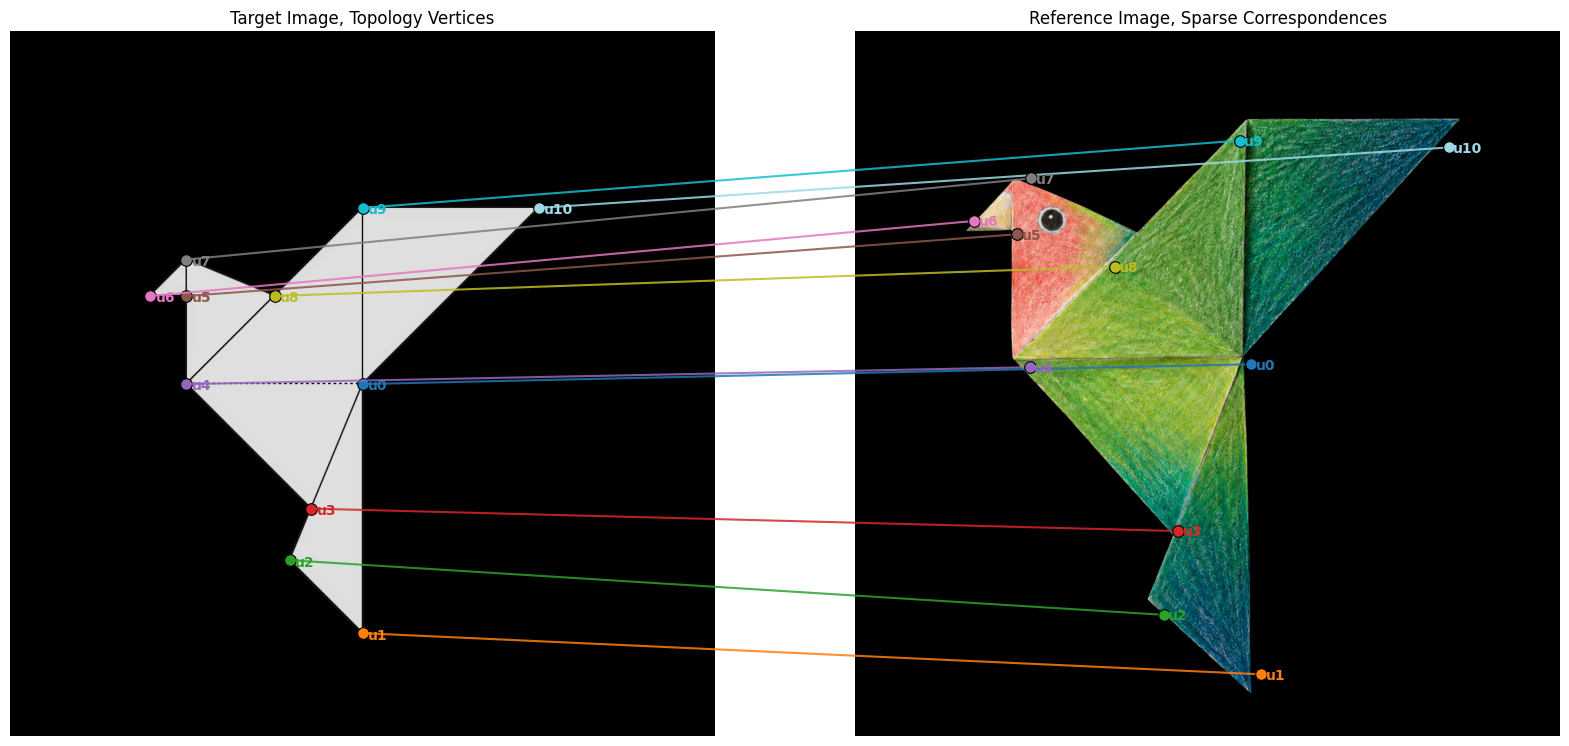

In [11]:
# image scale to go from resized patch coordinates to original image coordinates
scale_target = target_image.height / IMAGE_SIZE
scale_reference = reference_image.height / IMAGE_SIZE

target_topology_path = RAW_DATA_DIR / "dove-wingup-topology.json"
with open(target_topology_path, "r", encoding="utf-8") as file:
    target_topology = json.load(file)

topology_width, topology_height = target_topology["resolution"]
target_topology_scale_x = target_image.width / topology_width
target_topology_scale_y = target_image.height / topology_height

target_vertices = {
    vertex_id: tuple(coord)
    for vertex_id, coord in target_topology["vertices"].items()
}

target_h_patches, target_w_patches = patch_features[0].shape[1:]

reference_heatmaps = heatmaps.clone()
if "patch_mask_values" in globals():
    reference_fg_mask = patch_mask_values[1] > MASK_FG_THRESHOLD
    reference_heatmaps = reference_heatmaps.masked_fill(~reference_fg_mask[None, :, :], -torch.inf)


def point_to_nearest_patch_index(row_resized: float, col_resized: float, h_patches: int, w_patches: int) -> int:
    row_patch = int(np.clip(np.round(row_resized / PATCH_SIZE - 0.5), 0, h_patches - 1))
    col_patch = int(np.clip(np.round(col_resized / PATCH_SIZE - 0.5), 0, w_patches - 1))
    return row_patch * w_patches + col_patch


def refine_reference_point_from_heatmap(
    heatmap: torch.Tensor,
    window_radius: int = 2,
    temperature: float = 0.05,
) -> np.ndarray:
    if not torch.isfinite(heatmap).any():
        heatmap = torch.zeros_like(heatmap)

    best_index = torch.flatten(heatmap).argmax().item()
    best_row = best_index // heatmap.shape[1]
    best_col = best_index % heatmap.shape[1]

    row_start = max(best_row - window_radius, 0)
    row_end = min(best_row + window_radius + 1, heatmap.shape[0])
    col_start = max(best_col - window_radius, 0)
    col_end = min(best_col + window_radius + 1, heatmap.shape[1])

    local_scores = heatmap[row_start:row_end, col_start:col_end]
    finite_local_scores = torch.where(torch.isfinite(local_scores), local_scores, torch.tensor(-1e9, dtype=local_scores.dtype, device=local_scores.device))
    local_rows, local_cols = torch.meshgrid(
        torch.arange(row_start, row_end, dtype=local_scores.dtype, device=local_scores.device),
        torch.arange(col_start, col_end, dtype=local_scores.dtype, device=local_scores.device),
        indexing="ij",
    )

    weights = torch.softmax(finite_local_scores.flatten() / temperature, dim=0).reshape_as(finite_local_scores)
    row_resized = ((local_rows + 0.5) * PATCH_SIZE * weights).sum()
    col_resized = ((local_cols + 0.5) * PATCH_SIZE * weights).sum()
    return np.array([row_resized.item(), col_resized.item()])


target_vertex_ids = []
target_vertex_points_xy = []
matched_reference_points_yx = []

for vertex_id, (x_topology, y_topology) in target_vertices.items():
    x_target = x_topology * target_topology_scale_x
    y_target = y_topology * target_topology_scale_y

    row_resized = y_target / scale_target
    col_resized = x_target / scale_target
    target_patch_index = point_to_nearest_patch_index(
        row_resized,
        col_resized,
        target_h_patches,
        target_w_patches,
    )

    target_vertex_ids.append(vertex_id)
    target_vertex_points_xy.append((x_target, y_target))
    matched_reference_points_yx.append(refine_reference_point_from_heatmap(reference_heatmaps[target_patch_index]))

matched_reference_points_yx = np.array(matched_reference_points_yx)
matched_reference_points_xy = np.stack(
    (
        matched_reference_points_yx[:, 1] * scale_reference,
        matched_reference_points_yx[:, 0] * scale_reference,
    ),
    axis=1,
)
target_vertex_points_xy = np.array(target_vertex_points_xy, dtype=float)

print(f"Loaded {len(target_vertex_ids)} target vertices from {target_topology_path}")

# show original target and reference images
fig = plt.figure(figsize=(20, 10))
ax1 = fig.add_subplot(121)
ax1.imshow(image_on_black(target_image, target_alpha_mask))
ax1.set_title("Target Image, Topology Vertices")
ax1.set_axis_off()
ax2 = fig.add_subplot(122)
ax2.imshow(image_on_black(reference_image, reference_alpha_mask))
ax2.set_title("Reference Image, Sparse Correspondences")
ax2.set_axis_off()
colors = plt.cm.tab20(np.linspace(0, 1, len(target_vertex_ids)))

for vertex_id, (target_x, target_y), (reference_x, reference_y), color in zip(
    target_vertex_ids,
    target_vertex_points_xy,
    matched_reference_points_xy,
    colors,
):
    ax1.scatter(target_x, target_y, s=70, c=[color], edgecolors="black", linewidths=0.8, zorder=3)
    ax1.text(target_x + 8, target_y + 8, vertex_id, color=color, fontsize=10, weight="bold")

    ax2.scatter(reference_x, reference_y, s=70, c=[color], edgecolors="black", linewidths=0.8, zorder=3)
    ax2.text(reference_x + 8, reference_y + 8, vertex_id, color=color, fontsize=10, weight="bold")

    con = ConnectionPatch( 
        xyA=(target_x, target_y),
        xyB=(reference_x, reference_y),
        coordsA="data",
        coordsB="data",
        axesA=ax1,
        axesB=ax2,
        color=color,
        linewidth=1.5,
        alpha=0.85,
    )
    ax2.add_artist(con)


### Snap Sparse Matches to Contour Vertices

Move the sparse reference matches to nearby vertices extracted from the reference image contour.

Snapped 11/11 reference matches to 11 contour vertices within 78.4px


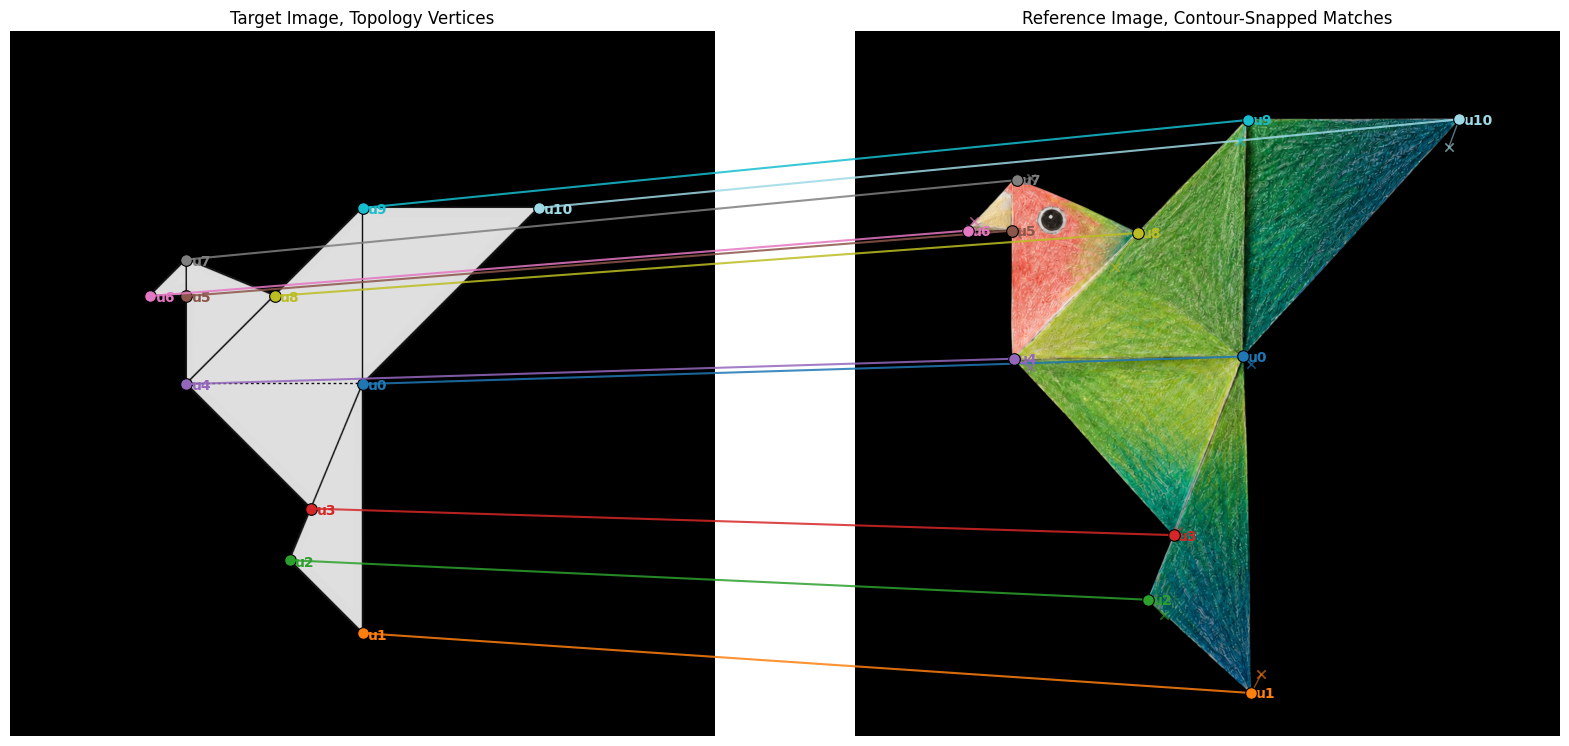

In [12]:
def extract_contour_vertices_xy(
    alpha_mask: torch.Tensor,
    approximation_epsilon_ratio: float = 0.012,
    min_contour_area: float = 100.0,
) -> np.ndarray:
    mask = (alpha_mask.detach().cpu().numpy() > 0.5).astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    vertices = []
    for contour in contours:
        if cv2.contourArea(contour) < min_contour_area:
            continue

        epsilon = approximation_epsilon_ratio * cv2.arcLength(contour, closed=True)
        approximated = cv2.approxPolyDP(contour, epsilon, closed=True)
        vertices.extend(approximated.reshape(-1, 2))

    if not vertices:
        return np.empty((0, 2), dtype=float)

    vertices_xy = np.array(vertices, dtype=float)
    return np.unique(np.round(vertices_xy, 2), axis=0)


def snap_points_to_nearest_vertices(
    points_xy: np.ndarray,
    vertices_xy: np.ndarray,
    max_distance: float | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if len(vertices_xy) == 0:
        return points_xy.copy(), np.full(len(points_xy), np.nan), np.zeros(len(points_xy), dtype=bool)

    deltas = points_xy[:, None, :] - vertices_xy[None, :, :]
    distances = np.linalg.norm(deltas, axis=2)
    nearest_indices = np.argmin(distances, axis=1)
    nearest_distances = distances[np.arange(len(points_xy)), nearest_indices]

    snapped_mask = np.ones(len(points_xy), dtype=bool)
    if max_distance is not None:
        snapped_mask = nearest_distances <= max_distance

    snapped_points_xy = points_xy.copy()
    snapped_points_xy[snapped_mask] = vertices_xy[nearest_indices[snapped_mask]]
    return snapped_points_xy, nearest_distances, snapped_mask


raw_matched_reference_points_xy = matched_reference_points_xy.copy()
reference_contour_vertices_xy = extract_contour_vertices_xy(reference_alpha_mask)
contour_snap_max_distance = 4 * min(reference_image.size) / (IMAGE_SIZE / PATCH_SIZE)
snapped_reference_points_xy, contour_snap_distances, contour_snapped_mask = snap_points_to_nearest_vertices(
    raw_matched_reference_points_xy,
    reference_contour_vertices_xy,
    max_distance=contour_snap_max_distance,
)

print(
    f"Snapped {contour_snapped_mask.sum()}/{len(contour_snapped_mask)} reference matches "
    f"to {len(reference_contour_vertices_xy)} contour vertices "
    f"within {contour_snap_max_distance:.1f}px"
)

# show target vertices and snapped reference matches
fig = plt.figure(figsize=(20, 10))
ax1 = fig.add_subplot(121)
ax1.imshow(image_on_black(target_image, target_alpha_mask))
ax1.set_title("Target Image, Topology Vertices")
ax1.set_axis_off()
ax2 = fig.add_subplot(122)
ax2.imshow(image_on_black(reference_image, reference_alpha_mask))
ax2.set_title("Reference Image, Contour-Snapped Matches")
ax2.set_axis_off()

if len(reference_contour_vertices_xy) > 0:
    ax2.scatter(
        reference_contour_vertices_xy[:, 0],
        reference_contour_vertices_xy[:, 1],
        s=28,
        marker="D",
        facecolors="none",
        edgecolors="white",
        linewidths=0.9,
        alpha=0.75,
        zorder=2,
    )

colors = plt.cm.tab20(np.linspace(0, 1, len(target_vertex_ids)))

for vertex_id, (target_x, target_y), (raw_reference_x, raw_reference_y), (reference_x, reference_y), was_snapped, color in zip(
    target_vertex_ids,
    target_vertex_points_xy,
    raw_matched_reference_points_xy,
    snapped_reference_points_xy,
    contour_snapped_mask,
    colors,
):
    ax1.scatter(target_x, target_y, s=70, c=[color], edgecolors="black", linewidths=0.8, zorder=3)
    ax1.text(target_x + 8, target_y + 8, vertex_id, color=color, fontsize=10, weight="bold")

    ax2.scatter(raw_reference_x, raw_reference_y, s=36, marker="x", c=[color], linewidths=1.2, alpha=0.65, zorder=3)
    if was_snapped:
        ax2.plot([raw_reference_x, reference_x], [raw_reference_y, reference_y], color=color, linewidth=1.0, alpha=0.55, zorder=3)
    ax2.scatter(reference_x, reference_y, s=70, c=[color], edgecolors="black", linewidths=0.8, zorder=4)
    ax2.text(reference_x + 8, reference_y + 8, vertex_id, color=color, fontsize=10, weight="bold")

    con = ConnectionPatch(
        xyA=(target_x, target_y),
        xyB=(reference_x, reference_y),
        coordsA="data",
        coordsB="data",
        axesA=ax1,
        axesB=ax2,
        color=color,
        linewidth=1.5,
        alpha=0.85,
    )
    ax2.add_artist(con)


### Topology Warping

Warp each snapped reference triangle back onto the original topology vertex coordinates.

Warped 6 topology faces


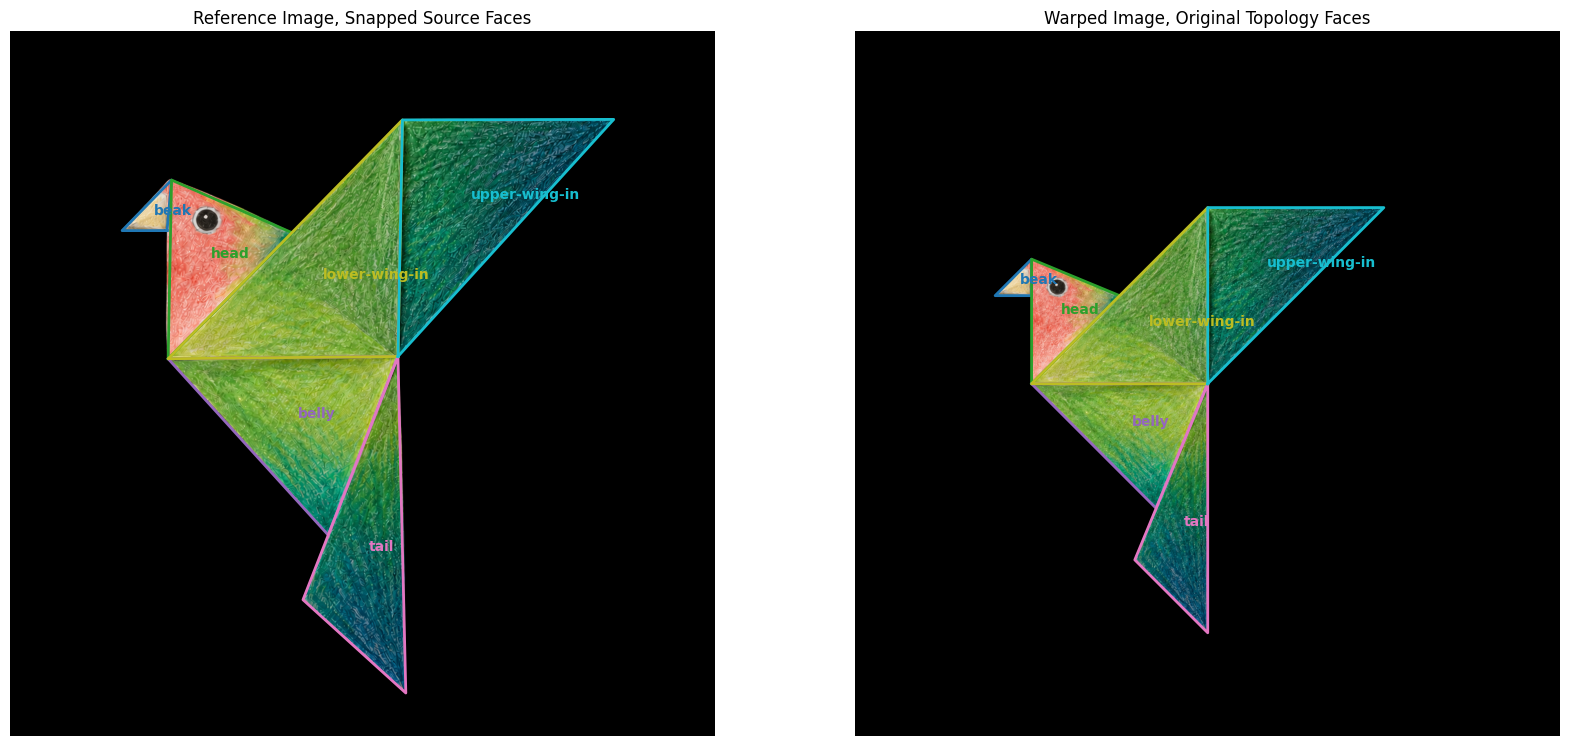

In [13]:
topology_width, topology_height = target_topology["resolution"]
topology_vertices_xy = {
    vertex_id: np.array(coord, dtype=np.float32)
    for vertex_id, coord in target_topology["vertices"].items()
}
snapped_reference_vertices_xy = {
    vertex_id: point.astype(np.float32)
    for vertex_id, point in zip(target_vertex_ids, snapped_reference_points_xy)
}

reference_rgba = np.array(reference_image.convert("RGBA"))
warp_rgba = np.zeros((topology_height, topology_width, 4), dtype=np.uint8)
face_masks = {}

for face_name, face_vertex_ids in target_topology["faces"].items():
    source_triangle = np.float32([snapped_reference_vertices_xy[vertex_id] for vertex_id in face_vertex_ids])
    destination_triangle = np.float32([topology_vertices_xy[vertex_id] for vertex_id in face_vertex_ids])

    affine = cv2.getAffineTransform(source_triangle, destination_triangle)
    warped_face = cv2.warpAffine(
        reference_rgba,
        affine,
        (topology_width, topology_height),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0, 0),
    )

    face_mask = np.zeros((topology_height, topology_width), dtype=np.uint8)
    cv2.fillConvexPoly(face_mask, np.round(destination_triangle).astype(np.int32), 255)
    face_masks[face_name] = face_mask

    masked_pixels = face_mask > 0
    warp_rgba[masked_pixels] = warped_face[masked_pixels]

warp_image = Image.fromarray(warp_rgba, mode="RGBA")
print(f"Warped {len(target_topology['faces'])} topology faces")

fig = plt.figure(figsize=(20, 10))
ax1 = fig.add_subplot(121)
ax1.imshow(image_on_black(reference_image, reference_alpha_mask))
ax1.set_title("Reference Image, Snapped Source Faces")
ax1.set_axis_off()

ax2 = fig.add_subplot(122)
ax2.imshow(image_on_black(warp_image))
ax2.set_title("Warped Image, Original Topology Faces")
ax2.set_xlim(0, topology_width)
ax2.set_ylim(topology_height, 0)
ax2.set_aspect("equal")
ax2.set_axis_off()

face_colors = plt.cm.tab10(np.linspace(0, 1, len(target_topology["faces"])))
for (face_name, face_vertex_ids), color in zip(target_topology["faces"].items(), face_colors):
    source_triangle = np.array([snapped_reference_vertices_xy[vertex_id] for vertex_id in face_vertex_ids])
    destination_triangle = np.array([topology_vertices_xy[vertex_id] for vertex_id in face_vertex_ids])

    source_closed = np.vstack([source_triangle, source_triangle[0]])
    destination_closed = np.vstack([destination_triangle, destination_triangle[0]])
    ax1.plot(source_closed[:, 0], source_closed[:, 1], color=color, linewidth=2.0)
    ax2.plot(destination_closed[:, 0], destination_closed[:, 1], color=color, linewidth=2.0)

    source_center = source_triangle.mean(axis=0)
    destination_center = destination_triangle.mean(axis=0)
    ax1.text(source_center[0], source_center[1], face_name, color=color, fontsize=10, weight="bold")
    ax2.text(destination_center[0], destination_center[1], face_name, color=color, fontsize=10, weight="bold")


### UV Mapping

Mapped 6 topology faces to a y=x symmetric flat net image


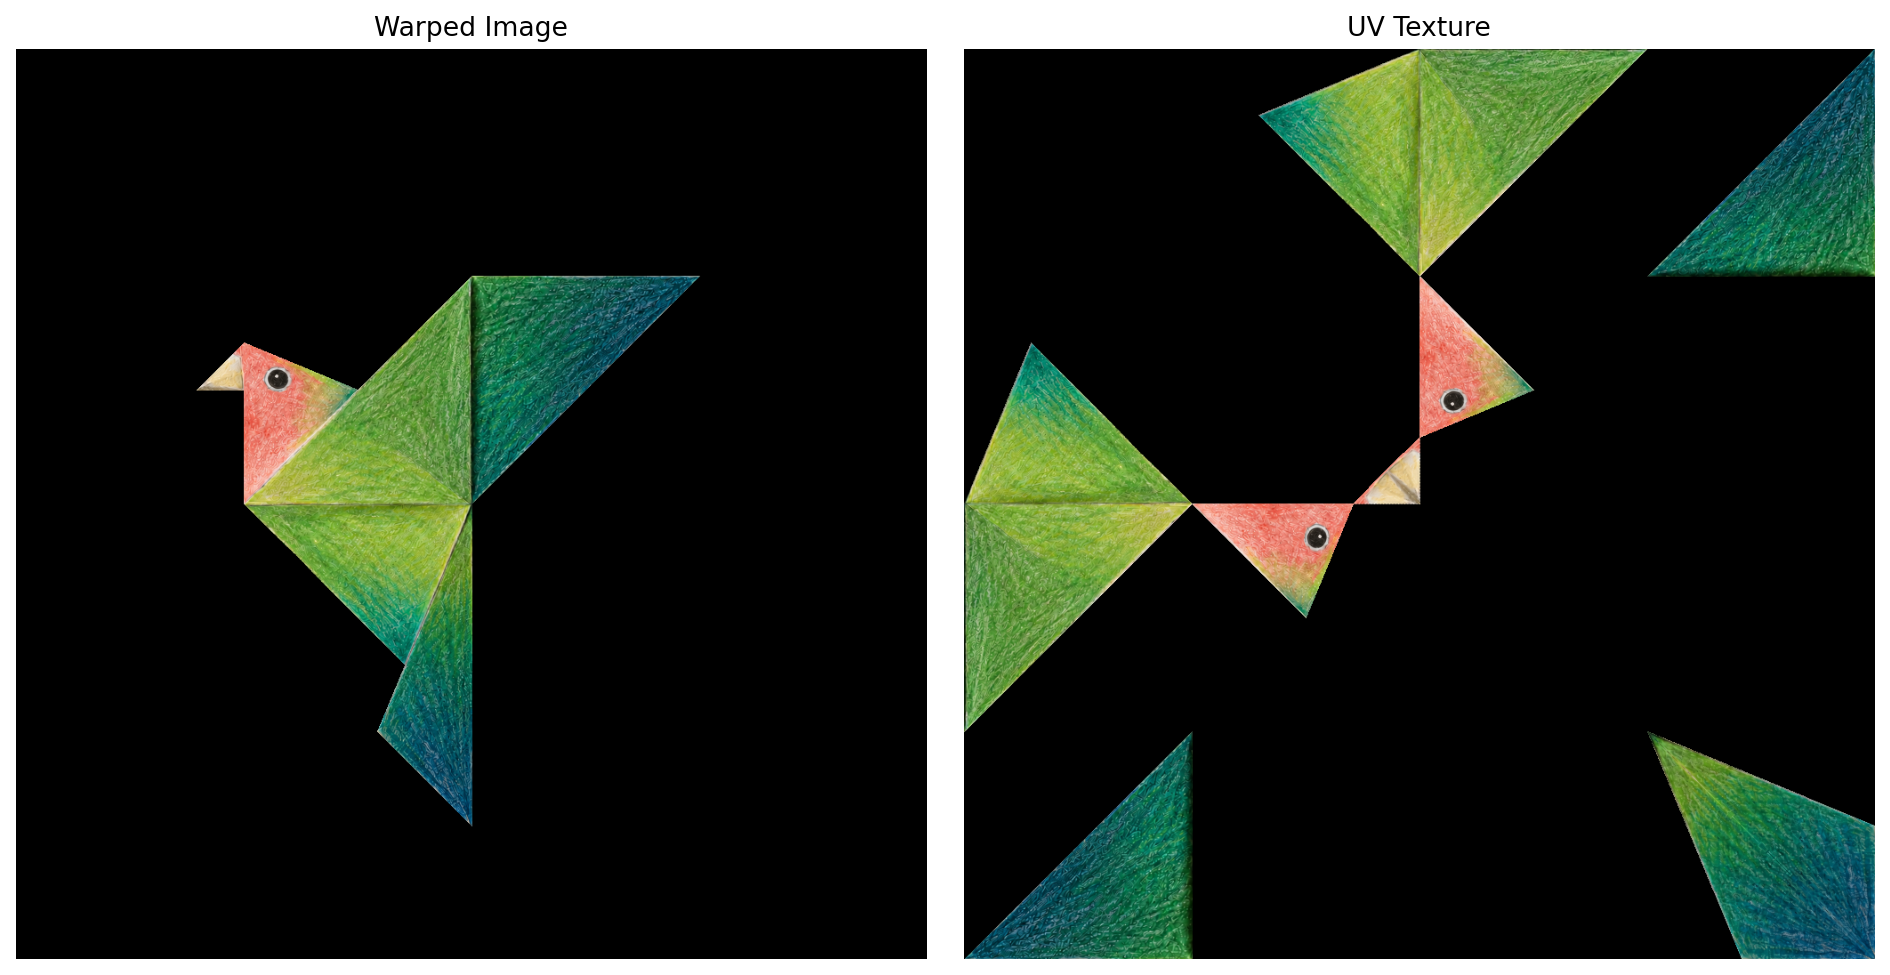

In [14]:
# Map dove-wingup topology face image pixels onto the flat origami net image.
topology_path = RAW_DATA_DIR / "dove-wingup-topology.json"
net_path = RAW_DATA_DIR / "dove-wingup-net.json"

with topology_path.open(encoding="utf-8") as f:
    wingup_topology = json.load(f)

with net_path.open(encoding="utf-8") as f:
    wingup_net = json.load(f)


def collect_points(data):
    points = {}
    for key in ("vertices", "features", "quaters", "quarters"):
        points.update(data.get(key, {}))
    return {name: np.asarray(xy, dtype=np.float32) for name, xy in points.items()}


def resolve_faces(data):
    points = collect_points(data)
    return {
        face_name: np.asarray([points[point_name] for point_name in point_names], dtype=np.float32)
        for face_name, point_names in data["faces"].items()
    }


topology_faces_xy = resolve_faces(wingup_topology)
net_faces_uv = resolve_faces(wingup_net)

missing_faces = sorted(set(topology_faces_xy) - set(net_faces_uv))
if missing_faces:
    raise KeyError(f"net json is missing faces from topology json: {missing_faces}")

# Use the topology-space texture from the previous warping block when it exists.
# If this cell is run alone, fall back to the target image drawn in topology coordinates.
source_topology_image = warp_image if "warp_image" in globals() else target_image
source_rgba = np.array(source_topology_image.convert("RGBA"), dtype=np.uint8)

source_height, source_width = source_rgba.shape[:2]
topology_width, topology_height = wingup_topology["resolution"]
net_width, net_height = wingup_net["resolution"]

source_scale = np.array(
    [source_width / topology_width, source_height / topology_height],
    dtype=np.float32,
)

uv_rgba = np.zeros((net_height, net_width, 4), dtype=np.uint8)

for face_name, source_triangle_topology in topology_faces_xy.items():
    source_triangle = source_triangle_topology * source_scale
    destination_triangle = net_faces_uv[face_name]

    affine = cv2.getAffineTransform(
        source_triangle.astype(np.float32),
        destination_triangle.astype(np.float32),
    )
    warped_face = cv2.warpAffine(
        source_rgba,
        affine,
        (net_width, net_height),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0, 0),
    )

    face_mask = np.zeros((net_height, net_width), dtype=np.uint8)
    cv2.fillConvexPoly(face_mask, np.round(destination_triangle).astype(np.int32), 255)

    pixels = face_mask > 0
    uv_rgba[pixels] = warped_face[pixels]

def make_decalcomanie_y_equals_x(rgba):
    if rgba.shape[0] != rgba.shape[1]:
        raise ValueError("y=x decalcomanie requires a square UV image")

    rgba = rgba.astype(np.float32)
    mirrored = np.transpose(rgba, (1, 0, 2))

    alpha = rgba[..., 3:4] / 255.0
    mirrored_alpha = mirrored[..., 3:4] / 255.0
    weight_sum = alpha + mirrored_alpha

    rgb = np.divide(
        rgba[..., :3] * alpha + mirrored[..., :3] * mirrored_alpha,
        np.maximum(weight_sum, 1e-6),
    )
    out_alpha = np.maximum(alpha, mirrored_alpha) * 255.0

    return np.clip(np.concatenate([rgb, out_alpha], axis=2), 0, 255).astype(np.uint8)


uv_rgba = make_decalcomanie_y_equals_x(uv_rgba)
uv_image = Image.fromarray(uv_rgba, mode="RGBA")
print(f"Mapped {len(topology_faces_xy)} topology faces to a y=x symmetric flat net image")

def rgba_on_black(image):
    rgba = np.array(image.convert("RGBA"), dtype=np.float32)
    alpha = rgba[..., 3:4] / 255.0
    return np.clip(rgba[..., :3] * alpha, 0, 255).astype(np.uint8)


fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=160)

axes[0].imshow(rgba_on_black(source_topology_image))
axes[0].set_title("Warped Image")
axes[0].set_axis_off()

axes[1].imshow(rgba_on_black(uv_image))
axes[1].set_title("UV Texture")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()





In [15]:
# Save the UV texture result into data/raw/texture.png
texture_path = RAW_DATA_DIR / "texture.png"

if "uv_image" not in globals():
    raise NameError("Run the UV mapping cell first so uv_image exists.")

uv_image.save(texture_path)
print(f"Saved UV texture to {texture_path}")


Saved UV texture to C:\Users\morph\GitHub\origami-texturing\data\raw\texture.png
